<a href="https://colab.research.google.com/github/mahipatel23ds-tech/finall-bank-froud/blob/main/Copy_of_Federated_Bank_Fraud_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Load dataset
data = pd.read_csv("/content/drive/MyDrive/mager project/credit_card_fraud_10k.csv")

# Show first 5 rows
data.head()


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0.0,0.0,66.0,3.0,40.0,0.0
1,2,541.82,3,Travel,1.0,0.0,87.0,1.0,64.0,0.0
2,3,237.01,17,Grocery,0.0,0.0,49.0,1.0,61.0,0.0
3,4,164.33,4,Grocery,0.0,1.0,72.0,3.0,34.0,0.0
4,5,30.53,15,Food,0.0,0.0,79.0,0.0,44.0,0.0


In [4]:
#Dataset Shape & Info
# Dataset shape
print("Rows, Columns:", data.shape)

# Dataset information
data.info()


Rows, Columns: (5458, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5458 entries, 0 to 5457
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       5458 non-null   int64  
 1   amount               5458 non-null   float64
 2   transaction_hour     5458 non-null   int64  
 3   merchant_category    5458 non-null   object 
 4   foreign_transaction  5457 non-null   float64
 5   location_mismatch    5457 non-null   float64
 6   device_trust_score   5457 non-null   float64
 7   velocity_last_24h    5457 non-null   float64
 8   cardholder_age       5457 non-null   float64
 9   is_fraud             5457 non-null   float64
dtypes: float64(7), int64(2), object(1)
memory usage: 426.5+ KB


In [5]:
# Count fraud and normal transactions
data['is_fraud'].value_counts()

,count
is_fraud,
0.0,5370
1.0,87


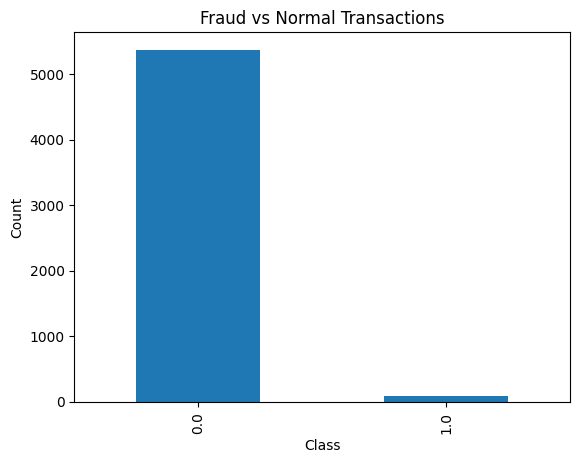

In [6]:
#Simple Visualization (Optional but Good)
data['is_fraud'].value_counts().plot(kind='bar')
plt.title("Fraud vs Normal Transactions")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [7]:
#Features–Labels Split & Simple ML Model
#Features (X) & Label (y) Separate

# Drop rows where 'is_fraud' is NaN
data_cleaned = data.dropna(subset=['is_fraud'])

# Convert 'merchant_category' to numerical using one-hot encoding
data_encoded = pd.get_dummies(data_cleaned, columns=['merchant_category'], drop_first=True)

# Features and target
X = data_encoded.drop('is_fraud', axis=1)
y = data_encoded['is_fraud']

print("Features shape:", X.shape)
print("Labels shape:", y.shape)

Features shape: (5457, 12)
Labels shape: (5457,)


In [8]:
#Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [9]:
#Simple Model Train
#Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [10]:
#Prediction & Accuracy
# Predictions
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)


Accuracy: 0.9917582417582418


In [11]:
#Detailed Result
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      1075
         1.0       0.79      0.65      0.71        17

    accuracy                           0.99      1092
   macro avg       0.89      0.82      0.85      1092
weighted avg       0.99      0.99      0.99      1092



In [12]:
# Shuffle dataset
data_shuffled = data_encoded.sample(frac=1, random_state=42).reset_index(drop=True)

In [13]:
#Dataset Ko 3 Equal Parts Me Divide karo
# Total samples
total_samples = len(data_shuffled)

# Split size
split_size = total_samples // 3

# Client datasets
client1 = data_shuffled.iloc[:split_size]
client2 = data_shuffled.iloc[split_size:2*split_size]
client3 = data_shuffled.iloc[2*split_size:]

print(len(client1), len(client2), len(client3))


1819 1819 1819


In [14]:
#Client Data Ko X & y Me Convert Karo
def split_xy(client_data):
    X = client_data.drop('is_fraud', axis=1)
    y = client_data['is_fraud']
    return X, y

X1, y1 = split_xy(client1)
X2, y2 = split_xy(client2)
X3, y3 = split_xy(client3)

In [15]:
#Function for Local Training
from sklearn.linear_model import LogisticRegression

def train_local_model(X, y):
    model = LogisticRegression(max_iter=1000)
    model.fit(X, y)
    return model


In [16]:
#Train Model on Each Client
# Client 1
model1 = train_local_model(X1, y1)

# Client 2
model2 = train_local_model(X2, y2)

# Client 3
model3 = train_local_model(X3, y3)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

In [17]:
#Prediction Example (Optional)
# Check client1 model on its data
y_pred1 = model1.predict(X1)
from sklearn.metrics import accuracy_score
print("Client 1 Accuracy:", accuracy_score(y1, y_pred1))


Client 1 Accuracy: 0.9917537108301264


In [18]:
#Extract Model Coefficients
# Extract weights
w1, b1 = model1.coef_, model1.intercept_
w2, b2 = model2.coef_, model2.intercept_
w3, b3 = model3.coef_, model3.intercept_


In [19]:
#Federated Averaging
# Average weights
w_avg = (w1 + w2 + w3) / 3
b_avg = (b1 + b2 + b3) / 3


In [20]:
# Create a new model
global_model = LogisticRegression(max_iter=1000)

# Set the averaged coefficients
global_model.coef_ = w_avg
global_model.intercept_ = b_avg
global_model.classes_ = np.array([0, 1])  # required

# Test global model on any dataset (e.g., combined test set)
X_test_combined = pd.concat([X1, X2, X3])
y_test_combined = pd.concat([y1, y2, y3])
y_pred_global = global_model.predict(X_test_combined)

print("Global Model Accuracy:", accuracy_score(y_test_combined, y_pred_global))


Global Model Accuracy: 0.9906542056074766


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


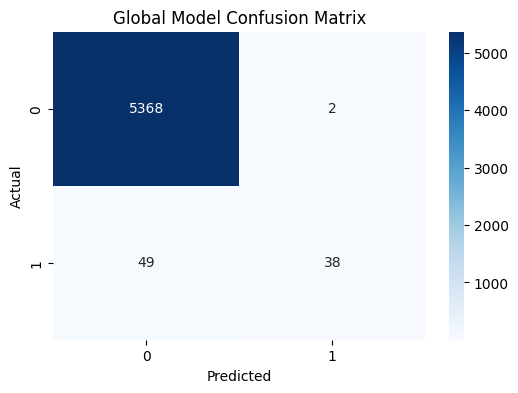

In [21]:
#Confusion Matrix Visualize
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Confusion matrix
cm = confusion_matrix(y_test_combined, y_pred_global)

# Plot
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Global Model Confusion Matrix")
plt.show()


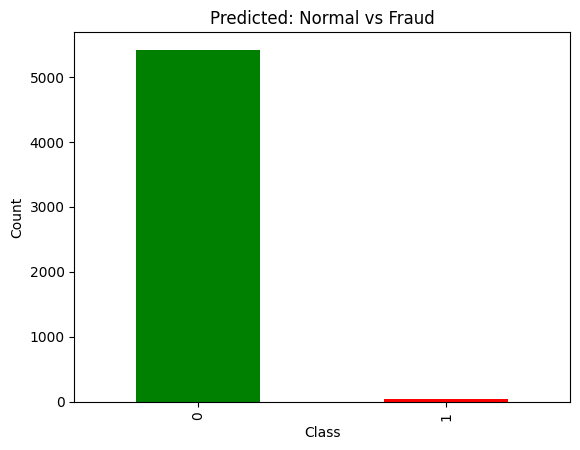

In [22]:
#Fraud vs Normal Prediction Count
import matplotlib.pyplot as plt

# Count of predicted classes
pred_counts = pd.Series(y_pred_global).value_counts()
pred_counts.plot(kind='bar', color=['green', 'red'])
plt.title("Predicted: Normal vs Fraud")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()


In [23]:
#Accuracy, Precision, Recall Report
from sklearn.metrics import classification_report

print("Global Model Classification Report:")
print(classification_report(y_test_combined, y_pred_global))


Global Model Classification Report:
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00      5370
         1.0       0.95      0.44      0.60        87

    accuracy                           0.99      5457
   macro avg       0.97      0.72      0.80      5457
weighted avg       0.99      0.99      0.99      5457



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


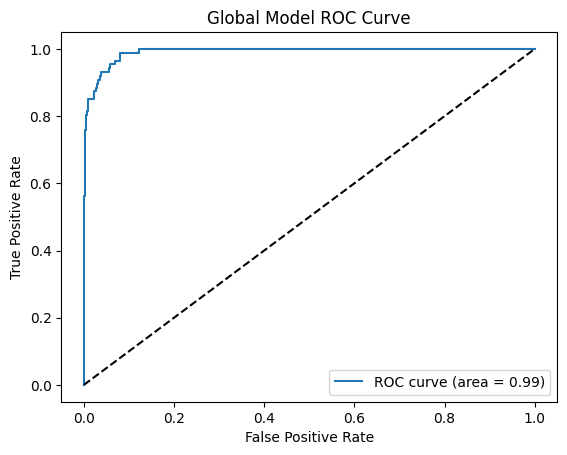

In [24]:
#ROC Curve(optional)
from sklearn.metrics import roc_curve, auc

y_prob = global_model.predict_proba(X_test_combined)[:,1]
fpr, tpr, thresholds = roc_curve(y_test_combined, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Global Model ROC Curve')
plt.legend(loc="lower right")
plt.show()


In [25]:
import numpy as np
import pandas as pd
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split # Ensure train_test_split is imported
from sklearn.utils.class_weight import compute_class_weight # Import for class weight calculation

# Load dataset (ensuring 'data' is defined)
data = pd.read_csv("/content/drive/MyDrive/mager project/credit_card_fraud_10k.csv")

# Drop rows where 'is_fraud' is NaN
data_cleaned = data.dropna(subset=['is_fraud'])

# Convert 'merchant_category' to numerical using one-hot encoding
data_encoded = pd.get_dummies(data_cleaned, columns=['merchant_category'], drop_first=True)

# Features and target
X = data_encoded.drop('is_fraud', axis=1)
y = data_encoded['is_fraud']

# 1. Scale the data first (fixes the convergence warning)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Re-split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Shuffle training dataset
data_shuffled = pd.concat([X_train, y_train], axis=1).sample(frac=1, random_state=42).reset_index(drop=True)

# Split into 3 equal clients
split_size = len(data_shuffled) // 3
client1 = data_shuffled.iloc[:split_size]
client2 = data_shuffled.iloc[split_size:2*split_size]
client3 = data_shuffled.iloc[2*split_size:]

def split_xy(client_data):
    # Corrected: Use 'is_fraud' instead of 'Class'
    return client_data.drop('is_fraud', axis=1), client_data['is_fraud']

X1, y1 = split_xy(client1)
X2, y2 = split_xy(client2)
X3, y3 = split_xy(client3)

# 2. Iterative Federated Learning Setup
NUM_ROUNDS = 5  # Number of communication rounds
# We use SGDClassifier because it supports "partial_fit" allowing models to be updated iteratively
# Initialize global_model WITHOUT class_weight='balanced'
global_model = SGDClassifier(loss='log_loss', random_state=42)

# Ensure classes are known to the global model immediately
# Use partial_fit with explicit classes to avoid ValueError if initial slice only contains one class
global_model.partial_fit(X1[:1].values, y1[:1].values, classes=np.array([0, 1]))

for round_num in range(1, NUM_ROUNDS + 1):
    print(f"\n--- Federated Learning Round {round_num} ---")

    # Ensure local models start with the current Global Model's weights
    # Local models are also initialized WITHOUT class_weight='balanced'
    model1 = SGDClassifier(loss='log_loss', warm_start=True, random_state=42)
    model2 = SGDClassifier(loss='log_loss', warm_start=True, random_state=42)
    model3 = SGDClassifier(loss='log_loss', warm_start=True, random_state=42)

    for m in [model1, model2, model3]:
        m.coef_ = np.copy(global_model.coef_)
        m.intercept_ = np.copy(global_model.intercept_)
        m.classes_ = np.array([0, 1])

    # Local Training on Clients with custom sample weights
    # Calculate class weights for each client's data
    client1_class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y1)
    client1_sample_weight = np.array([client1_class_weights[int(label)] for label in y1])
    model1.partial_fit(X1.values, y1.values, sample_weight=client1_sample_weight)

    client2_class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y2)
    client2_sample_weight = np.array([client2_class_weights[int(label)] for label in y2])
    model2.partial_fit(X2.values, y2.values, sample_weight=client2_sample_weight)

    client3_class_weights = compute_class_weight(class_weight='balanced', classes=np.array([0, 1]), y=y3)
    client3_sample_weight = np.array([client3_class_weights[int(label)] for label in y3])
    model3.partial_fit(X3.values, y3.values, sample_weight=client3_sample_weight)

    # Extract Local Weights & Biases
    w1, b1 = model1.coef_, model1.intercept_
    w2, b2 = model2.coef_, model2.intercept_
    w3, b3 = model3.coef_, model3.intercept_

    # 3. Privacy Preserving feature: Add Differential Privacy (Laplace Noise)
    # We add minor noise to obfuscate precise weights before sharing them with the server.
    noise_multiplier = 0.001
    w1 += np.random.laplace(0, noise_multiplier, w1.shape)
    w2 += np.random.laplace(0, noise_multiplier, w2.shape)
    w3 += np.random.laplace(0, noise_multiplier, w3.shape)

    # Federated Averaging (Server Side)
    w_avg = (w1 + w2 + w3) / 3
    b_avg = (b1 + b2 + b3) / 3

    # Update Global Model
    global_model.coef_ = w_avg
    global_model.intercept_ = b_avg

    # Evaluate Global Model at the end of the round
    y_pred_global = global_model.predict(X_test.values)
    round_acc = accuracy_score(y_test, y_pred_global)
    print(f"Global Model Accuracy after Round {round_num}: {round_acc:.4f}")

# Final detailed report
print("\nFinal Global Model Performance:")
print(classification_report(y_test, y_pred_global))


--- Federated Learning Round 1 ---
Global Model Accuracy after Round 1: 0.8938

--- Federated Learning Round 2 ---
Global Model Accuracy after Round 2: 0.8626

--- Federated Learning Round 3 ---
Global Model Accuracy after Round 3: 0.8892

--- Federated Learning Round 4 ---
Global Model Accuracy after Round 4: 0.8819

--- Federated Learning Round 5 ---
Global Model Accuracy after Round 5: 0.9084

Final Global Model Performance:
              precision    recall  f1-score   support

         0.0       1.00      0.91      0.95      1075
         1.0       0.15      1.00      0.25        17

    accuracy                           0.91      1092
   macro avg       0.57      0.95      0.60      1092
weighted avg       0.99      0.91      0.94      1092



In [26]:
!pip install flask-cors
from flask import Flask, request, jsonify
from flask_cors import CORS
import numpy as np
import pandas as pd

app = Flask(__name__)
CORS(app)

# Use your trained global_model
model = global_model

@app.route("/")
def home():
    return "Federated Fraud Detection API Running"

@app.route("/predict", methods=["POST"])
def predict():
    data = request.json
    features = np.array(data["features"]).reshape(1, -1)

    prediction = model.predict(features)
    prob = model.predict_proba(features)[0][1]

    return jsonify({
        "fraud": int(prediction[0]),
        "probability": float(prob)
    })

# NEW ENDPOINT: Gives the frontend a sample of the real dataset
@app.route("/data", methods=["GET"])
def get_dataset():
    # Randomly get a mix of Safe and Fraudulent transactions to demonstrate
    # Ensure 'data' variable is the pd.DataFrame you loaded earlier in Colab
    sample = pd.concat([
        data[data['Class'] == 0].sample(7),
        data[data['Class'] == 1].sample(3)
    ]).sample(frac=1) # shuffle them to look natural

    records = []
    import random
    for idx, row in sample.iterrows():
        records.append({
            "id": f"C:{int(row['Time'])}:{idx}",
            "amount": float(row["Amount"]),
            "isFraud": int(row["Class"])
        })

    return jsonify(records)




from threading import Thread

def run_app():
    app.run(port=5000)

thread = Thread(target=run_app)
thread.start()

In [27]:
from flask_cors import CORS
CORS(app)

In [28]:
!pip install pyngrok

 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


In [29]:
from pyngrok import ngrok

ngrok.set_auth_token("3CIOrhiGYsLZkBwsxp4nCdnKxmd_7rRj2DB8kSwyUmVzmNQeQ")

# Kill any existing ngrok tunnels
ngrok.kill()

public_url = ngrok.connect(5000)
print(public_url)

NgrokTunnel: "https://quicksand-scuff-defender.ngrok-free.dev" -> "http://localhost:5000"
